# Spatial Relationships in GeoPandas

## Introduction

We have now become familiar with a `GeoDataFrame` and how to use it. We will spend the last notebook today exploring our full range of options for properly utilising spatial relationships.

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box

Now, as well as the country dataset we previously downloaded, we are going to include a new global cities dataset: the [Natural Earth Populated Places dataset](https://www.naturalearthdata.com/downloads/50m-cultural-vectors/). A cleaned version for this class can be downloaded [at the following link](https://raw.githubusercontent.com/trchudley/geospatial-scientific-computing/main/week/03/nat_earth_cities.gpkg). Make sure both are in the same directory as the notebook when they are loaded:

In [9]:
countries_gdf = gpd.read_file('nat_earth_countries.gpkg')
cities_gdf = gpd.read_file('nat_earth_cities.gpkg')

Now, we have an additoinal `Point` dataset of cities as well as `MultiPolygon` set of countries:

In [10]:
cities_gdf.head(5)

,NAME,ADM0NAME,ISO_A2,ADM1NAME,LATITUDE,LONGITUDE,POP_MAX,RANK_MAX,CAPIN,MEGACITY,geometry
0,Bombo,Uganda,UG,Bamunanika,0.583299,32.533300,75000,8,None,0,POINT (32.5333 0.5833)
1,Fort Portal,Uganda,UG,Kabarole,0.671004,30.275002,42670,7,None,0,POINT (30.275 0.671)
2,Potenza,Italy,IT,Basilicata,40.642002,15.798997,69060,8,None,0,POINT (15.799 40.642)
3,Campobasso,Italy,IT,Molise,41.562999,14.655997,50762,8,None,0,POINT (14.656 41.563)
4,Aosta,Italy,IT,Valle d'Aosta,45.737001,7.315003,34062,7,None,0,POINT (7.315 45.737)


Most of these new columns are self-explanatory, with a few exceptions (`'CAPIN'` is whether the city is a capital' `ISO_A2` refers to the standard two-letter country code). Note that `'MEGACITY'` is either `1` or `0`, not `True` or `False`.

We can plot both of these datasets within the same axes:

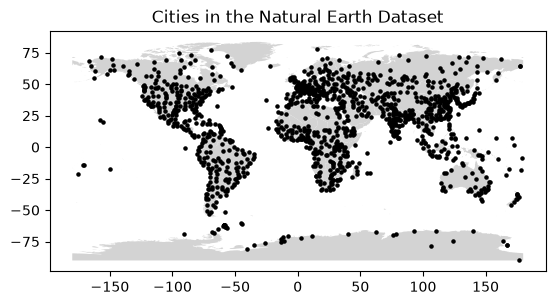

In [118]:
fig, ax = plt.subplots()

countries_gdf.plot(ax=ax, color='lightgrey')
cities_gdf.plot(ax=ax, color='black', markersize=5)

ax.set_title('Cities in the Natural Earth Dataset')

plt.show()

## Topological Relations

When working with geospatial data, operations can help you filter and manipulate data based how data is located relative to one another. We can think of this like mathematical comparisons (less than, equal to, etc.) but in a geographic space: the result of these queries are still a `bool` `True`/`False`.

Some common spatial relationships are shown below. Commonly used relations, such as _contains_, _intersects_, _overlaps_, and _touches_, are frequently ued to filter and join data based on their relations.

```{figure} ../../img/spatial-relations.png
:alt: pandas dataframe anatomy
:class: bh-primary
:width: 450px
:align: center
Common spatial relationships (Credit: [pythongis.org](https://pythongis.org))
```

These features are implemented within both `shapely` and, consequently, `geopandas`, as e.g. `.intersects()`, `.touches()`, `.covers()`.

We can use `.intersects()` to solve a problem from the previous notebook. I said that by using `clip` function, we would lose data outside the boundaries we had clipped to. What if we simply wanted to get all of the countries that were within a geographic boundary, but didn't want to clip any information? We could use `.intersect()`:

In [18]:
bounds = 15, 46, 17, 47  # xmin, xmax, ymin, ymax in ˚ lat/lon
bounding_box = box(*bounds)

countries_intersect_bool = countries_gdf.intersects(bounding_box)

countries_intersect_bool

0      False
1      False
2      False
3      False
4      False
       ...  
237    False
238    False
239    False
240    False
241    False
Length: 242, dtype: bool

We can use this boolean list to filter our countries list:

In [22]:
countries_gdf_intersect = countries_gdf[countries_intersect_bool]

countries_gdf_intersect

,ADMIN,CONTINENT,REGION_UN,SUBREGION,POP_EST,POP_RANK,GDP_MD,INCOME_GRP,ISO_A3,ISO_A2,geometry
61,Slovenia,Europe,Europe,Southern Europe,2087946.0,12,54174,1. High income: OECD,SVN,SI,"MULTIPOLYGON (((16.51621 46.4999, 16.42764 46...."
146,Hungary,Europe,Europe,Eastern Europe,9769949.0,13,163469,1. High income: OECD,HUN,HU,"MULTIPOLYGON (((22.13184 48.40532, 22.22715 48..."
188,Croatia,Europe,Europe,Southern Europe,4067500.0,12,60752,2. High income: nonOECD,HRV,HR,"MULTIPOLYGON (((13.57793 45.51689, 13.61523 45..."
224,Austria,Europe,Europe,Western Europe,8877067.0,13,445075,1. High income: OECD,AUT,AT,"MULTIPOLYGON (((9.52754 47.27075, 9.60908 47.3..."


<Axes: >

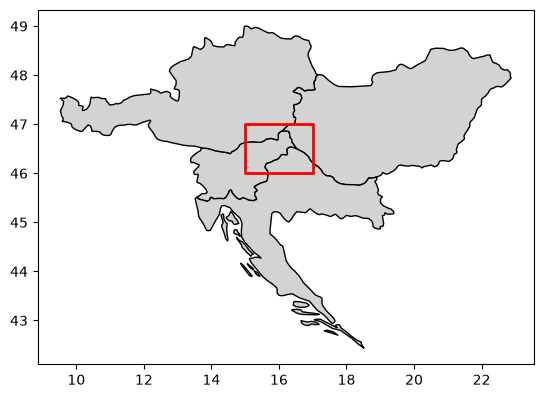

In [26]:
fig, ax = plt.subplots()

countries_gdf_intersect.plot(ax=ax, color='lightgrey', edgecolor='black')

# to plot our bounding_box, we can turn it into a geopandas dataframe and plot it
bounding_box_gdf = gpd.GeoDataFrame(geometry=[bounding_box], crs=countries_gdf.crs)
bounding_box_gdf.plot(ax=ax, color='none', edgecolor='red', linewidth=2)

For another example, let's find countries that border (i.e. `.touch()`) a landlocked country: 

In [37]:
niger_gdf = countries_gdf[countries_gdf['ADMIN'] == 'Niger']

# Get the geometry of Niger as a shapely object, extracting the first (and only) row of the geometry GeoDataSeries
niger_geometry = niger_gdf.geometry.iloc[0]  

niger_touches_bool = countries_gdf.touches(niger_geometry)

niger_neighbours_gdf = countries_gdf[niger_touches_bool]

niger_neighbours_gdf

,ADMIN,CONTINENT,REGION_UN,SUBREGION,POP_EST,POP_RANK,GDP_MD,INCOME_GRP,ISO_A3,ISO_A2,geometry
90,Nigeria,Africa,Africa,Western Africa,200963599.0,17,448120,4. Lower middle income,NGA,NG,"MULTIPOLYGON (((7.30078 4.41816, 7.20391 4.387..."
113,Mali,Africa,Africa,Western Africa,19658031.0,14,17279,5. Low income,MLI,ML,"MULTIPOLYGON (((-11.3894 12.40439, -11.38242 1..."
122,Libya,Africa,Africa,Northern Africa,6777452.0,13,52091,3. Upper middle income,LBY,LY,"MULTIPOLYGON (((9.51875 30.22939, 9.63799 30.2..."
199,Chad,Africa,Africa,Middle Africa,15946876.0,14,11314,5. Low income,TCD,TD,"MULTIPOLYGON (((23.98027 19.49663, 23.98066 19..."
207,Burkina Faso,Africa,Africa,Western Africa,20321378.0,15,15990,5. Low income,BFA,BF,"MULTIPOLYGON (((0.90049 10.99326, 0.64297 10.9..."
215,Benin,Africa,Africa,Western Africa,11801151.0,14,14390,5. Low income,BEN,BJ,"MULTIPOLYGON (((1.62266 6.2168, 1.61094 6.2508..."
235,Algeria,Africa,Africa,Northern Africa,43053054.0,15,171091,3. Upper middle income,DZA,DZ,"MULTIPOLYGON (((8.57656 36.93721, 8.59766 36.8..."


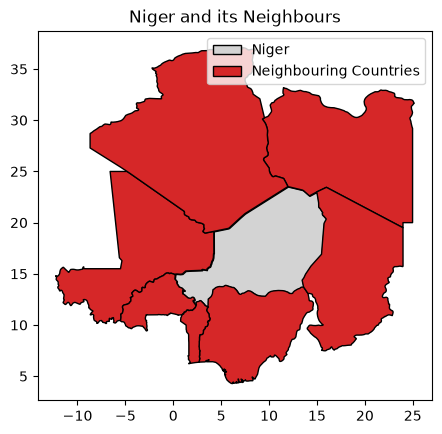

In [54]:
fig, ax = plt.subplots()

ax.set_title('Niger and its Neighbours')

niger_gdf.plot(ax=ax, color='lightgrey', edgecolor='black', label='Niger')
niger_neighbours_gdf.plot(ax=ax, color='tab:red', edgecolor='black', label='Neighbouring Countries')

ax.legend()

plt.show()


Let's begin to bring in our city data, and find out what UK cities are included by making use of the `within()` function.

In [55]:
uk_gdf = countries_gdf[countries_gdf['ADMIN'] == 'United Kingdom']
uk_geometry = uk_gdf.geometry.iloc[0]

uk_cities_mask = cities_gdf.within(uk_geometry)
uk_cities_gdf = cities_gdf[uk_cities_mask]

uk_cities_gdf

,NAME,ADM0NAME,ISO_A2,ADM1NAME,LATITUDE,LONGITUDE,POP_MAX,RANK_MAX,CAPIN,MEGACITY,geometry
93,Edinburgh,United Kingdom,GB,Edinburgh,55.948328,-3.219091,504966,11,None,0,POINT (-3.21909 55.94833)
94,Cardiff,United Kingdom,GB,Cardiff,51.499995,-3.225008,861400,11,None,0,POINT (-3.1676 51.48262)
126,Manchester,United Kingdom,GB,Manchester,53.502361,-2.249933,2230000,12,None,1,POINT (-2.24868 53.47532)
236,Birmingham,United Kingdom,GB,West Midlands,52.476920,-1.921943,2285000,12,None,1,POINT (-1.92194 52.47692)
237,Belfast,United Kingdom,GB,Belfast,54.600012,-5.960034,450406,10,None,0,POINT (-5.92818 54.59425)
786,Glasgow,United Kingdom,GB,Glasgow,55.876351,-4.252653,1160000,12,None,1,POINT (-4.2391 55.86227)
1227,London,United Kingdom,GB,Westminster,51.501941,-0.118668,8567000,13,None,1,POINT (-0.11867 51.50194)


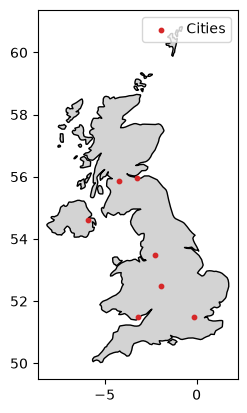

In [59]:
fig, ax = plt.subplots()

uk_gdf.plot(ax=ax, color='lightgrey', edgecolor='black')
uk_cities_gdf.plot(ax=ax, color='tab:red', markersize=10, label='Cities')

ax.legend()

plt.show()

## Vector Overlays

We already covered the basics of vector overlays in the `shapely` content, but is worth highlighting here how we can make things work within `geopandas` at teh `GeoDataFrame` level, not just individual geometries. Examples of vector overlays include the following:

```{figure} ../../img/spatial-relations.png
:alt: pandas dataframe anatomy
:class: bh-primary
:width: 450px
:align: center
Common vector overlay operations (Credit: [pythongis.org](https://pythongis.org))
```

Let's do some examples by converting the UK data into British National Grid (so we can work in metres, not degrees of lat/lon), and get a 150 km radius around London to play with.

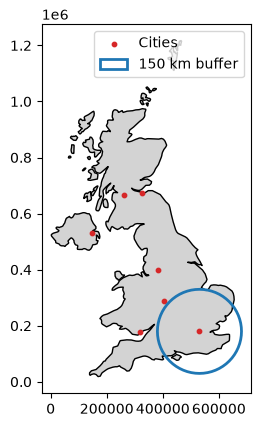

In [ ]:
# convert UK datasets to British National Grid (EPSG:27700) for metric distance calculations
uk_gdf_bng = uk_gdf.to_crs(epsg=27700)
uk_cities_gdf_bng = uk_cities_gdf.to_crs(epsg=27700)

# Get a 50 km buffer around London
london_geometry = uk_cities_gdf_bng[uk_cities_gdf_bng['NAME'] == 'London'].geometry.iloc[0]
london_buffer = london_geometry.buffer(150000)  # 150 km buffer
london_buffer_gdf = gpd.GeoDataFrame(geometry=[london_buffer], crs=uk_cities_gdf_bng.crs)

# plot the UK, cities, and the London buffer
fig, ax = plt.subplots()
uk_gdf_bng.plot(ax=ax, color='lightgrey', edgecolor='black')
uk_cities_gdf_bng.plot(ax=ax, color='tab:red', markersize=10, label='Cities')
london_buffer_gdf.plot(ax=ax, color='none', edgecolor='tab:blue', linewidth=2, label='150 km buffer')

ax.legend()

plt.show()

Note how we can see where the horizontal datum is (`0`, `0`), at a combination of the southernmost and westernmost point in the UK.

Now, we can play. `.intersection()` returns a vector made up of the area where both vectors exist:

<Axes: >

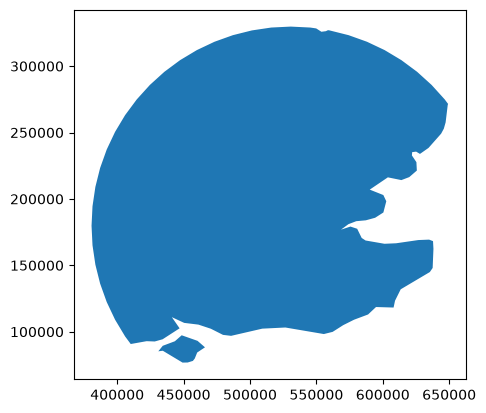

In [68]:
intersection = uk_gdf_bng.intersection(london_buffer)

intersection.plot()

`.union()` returns a vector made of where _either_ vector exists:

<Axes: >

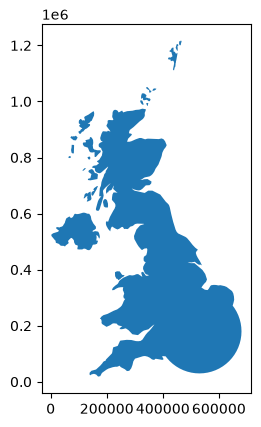

In [69]:
union = uk_gdf_bng.union(london_buffer)

union.plot()

`.difference()` returns the input layer, but only where the geometry provided as an argument _doesn't_ exist.

<Axes: >

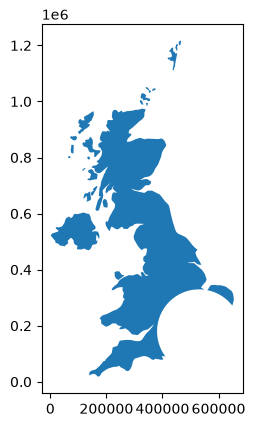

In [70]:
difference = uk_gdf_bng.difference(london_buffer)

difference.plot()

And the `.symmetric_difference()` performs similar to `.difference()`, but also returns where where the two datasets do _not_ overlap.

<Axes: >

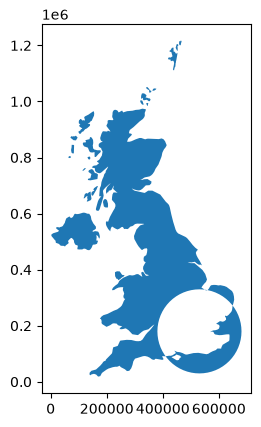

In [71]:
# symmetric difference
symmetric_difference = uk_gdf_bng.symmetric_difference(london_buffer)

symmetric_difference.plot()

## Spatial Join

If you have previous database experience, you might be familiar with the "join". This involves adding columns from one dataset to columns from another, based on a mutual shared column. For instance, our country and city datasets both contain the `ISO_A2` column: the standard two-letter country code.

In [74]:
countries_gdf.head(5)

,ADMIN,CONTINENT,REGION_UN,SUBREGION,POP_EST,POP_RANK,GDP_MD,INCOME_GRP,ISO_A3,ISO_A2,geometry
0,Zimbabwe,Africa,Africa,Eastern Africa,14645468.0,14,21440,5. Low income,ZWE,ZW,"MULTIPOLYGON (((31.28789 -22.40205, 31.19727 -..."
1,Zambia,Africa,Africa,Eastern Africa,17861030.0,14,23309,4. Lower middle income,ZMB,ZM,"MULTIPOLYGON (((30.39609 -15.64307, 30.25068 -..."
2,Yemen,Asia,Asia,Western Asia,29161922.0,15,22581,4. Lower middle income,YEM,YE,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,Vietnam,Asia,Asia,South-Eastern Asia,96462106.0,16,261921,4. Lower middle income,VNM,VN,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,Venezuela,South America,Americas,South America,28515829.0,15,482359,3. Upper middle income,VEN,VE,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."


In [85]:
print(cities_gdf['ISO_A2'].dtype)
print(countries_gdf['ISO_A2'].dtype)

object
object


In [75]:
cities_gdf.head(5)

,NAME,ADM0NAME,ISO_A2,ADM1NAME,LATITUDE,LONGITUDE,POP_MAX,RANK_MAX,CAPIN,MEGACITY,geometry
0,Bombo,Uganda,UG,Bamunanika,0.583299,32.533300,75000,8,None,0,POINT (32.5333 0.5833)
1,Fort Portal,Uganda,UG,Kabarole,0.671004,30.275002,42670,7,None,0,POINT (30.275 0.671)
2,Potenza,Italy,IT,Basilicata,40.642002,15.798997,69060,8,None,0,POINT (15.799 40.642)
3,Campobasso,Italy,IT,Molise,41.562999,14.655997,50762,8,None,0,POINT (14.656 41.563)
4,Aosta,Italy,IT,Valle d'Aosta,45.737001,7.315003,34062,7,None,0,POINT (7.315 45.737)


Therefore, if we want to add datafrom the country dataset to the city dataset, we can do so based on that relationship. For instance, using plain (not geo-) pandas, we can add the `CONTINENT` of every city as an additional column by joining with the countries dataframe:

In [ ]:
cities_continent_gdf = cities_gdf.join(
    countries_gdf.set_index('ISO_A2')[['CONTINENT']],  # the 'right-hand' dataframe must be indexed by the column we wish to `join`.
    on='ISO_A2', 
    how='left'  # 'left' means the input/left hand dataframe (cities_gdf) will be preserved, and the right-hand dataframe (countries_gdf) will be joined to it based on the 'ISO_A2' column.
)

cities_continent_gdf.head(5)

,NAME,ADM0NAME,ISO_A2,ADM1NAME,LATITUDE,LONGITUDE,POP_MAX,RANK_MAX,CAPIN,MEGACITY,geometry,CONTINENT
0,Bombo,Uganda,UG,Bamunanika,0.583299,32.533300,75000,8,None,0,POINT (32.5333 0.5833),Africa
1,Fort Portal,Uganda,UG,Kabarole,0.671004,30.275002,42670,7,None,0,POINT (30.275 0.671),Africa
2,Potenza,Italy,IT,Basilicata,40.642002,15.798997,69060,8,None,0,POINT (15.799 40.642),Europe
3,Campobasso,Italy,IT,Molise,41.562999,14.655997,50762,8,None,0,POINT (14.656 41.563),Europe
4,Aosta,Italy,IT,Valle d'Aosta,45.737001,7.315003,34062,7,None,0,POINT (7.315 45.737),Europe


However, what if we don't have a handy shared column? We can do this based upon shared geographic space. Below, we use the `geopandas.sjoin()` to do this, looking to add a `CONTINENT` column to the point city data based on if it lies `within` a Polygon:

In [ ]:
cities_continent_gdf = gpd.sjoin(
    cities_gdf,
    countries_gdf[['CONTINENT', 'geometry']],
    how='left',
    predicate='within'  # 'within' means we are looking for cities that are located within the boundaries of countries
)

cities_continent_gdf.head(5)

,NAME,ADM0NAME,ISO_A2,ADM1NAME,LATITUDE,LONGITUDE,POP_MAX,RANK_MAX,CAPIN,MEGACITY,geometry,index_right,CONTINENT
0,Bombo,Uganda,UG,Bamunanika,0.583299,32.533300,75000,8,None,0,POINT (32.5333 0.5833),34.0,Africa
1,Fort Portal,Uganda,UG,Kabarole,0.671004,30.275002,42670,7,None,0,POINT (30.275 0.671),34.0,Africa
2,Potenza,Italy,IT,Basilicata,40.642002,15.798997,69060,8,None,0,POINT (15.799 40.642),137.0,Europe
3,Campobasso,Italy,IT,Molise,41.562999,14.655997,50762,8,None,0,POINT (14.656 41.563),137.0,Europe
4,Aosta,Italy,IT,Valle d'Aosta,45.737001,7.315003,34062,7,None,0,POINT (7.315 45.737),137.0,Europe


Think about how this might be useful - for instance, if you had a dataframe of `Point` school locations as your "left hand" origin dataset, you could add information about which local authority each school is in. For a dataframe of earthquake origin positions, you could add which tectonic plate `Polygon` it falls in. For a given range of water sampling points, you could find out which watershed it lies within.

As usual, this is merely scratching the surface of this powerful tool! 

## Nearest Neighbours

Sometimes, you might have two datasets you need to compare, but find that they do not overlap, or touch, or have any useful relationship that allows you to use the above techniques. Here, you might wish to use "Nearest Neighbour analysis". 

For this problem, we are going to calculate the nearest megacity to every non-megacity.

Below, we will split our dataset into two: megacities and non-megacities cities, based on the threshold of 10 million people. We are also going to convert to an ['equidistant cylindrical'](https://epsg.io/4087) projection, which is a global projetion in metres that is useful for these sort of calculations. 

In [109]:
# cities where POP_MAX is greater than 10 million
megacities_gdf = cities_gdf[cities_gdf['POP_MAX'] >= 10000000]
othercities_gdf = cities_gdf[cities_gdf['POP_MAX'] < 10000000]

# so that we can find distances, change CRS to equidistant cylindrical projection (EPSG:4087) 
megacities_projected = megacities_gdf.to_crs("EPSG:4087")
othercities_projected = othercities_gdf.to_crs("EPSG:4087")

megacities_projected


,NAME,ADM0NAME,ISO_A2,ADM1NAME,LATITUDE,LONGITUDE,POP_MAX,RANK_MAX,CAPIN,MEGACITY,geometry
1097,Karachi,Pakistan,PK,Sind,24.871938,66.988063,12130000,14,None,1,POINT (7457077.074 2751868.505)
1150,Delhi,India,IN,Delhi,28.671939,77.228058,15926000,14,None,1,POINT (8596988.114 3172909.296)
1177,Dhaka,Bangladesh,BD,Dhaka,23.725006,90.406634,12797394,14,None,1,POINT (10064020.417 2624831.308)
1203,Manila,Philippines,PH,Metropolitan Manila,14.606105,120.980271,11100000,14,"Official, de fa",1,POINT (13467462.197 1615406.346)
1208,Ōsaka,Japan,JP,Osaka,34.751981,135.458199,11294000,14,None,1,POINT (15084208.917 3840323.703)
1218,Buenos Aires,Argentina,AR,Ciudad de Buenos Aires,-34.600556,-58.399477,12795000,14,None,1,POINT (-6504677.558 -3831406.74)
1224,Los Angeles,United States of America,US,California,33.991924,-118.181926,12500000,14,None,1,POINT (-13161524.53 3769120.982)
1226,New York,United States of America,US,New York,40.751925,-73.981963,19040000,14,UN Headquarters,1,POINT (-8237165.598 4509652.384)
1228,Istanbul,Turkey,TR,Istanbul,41.106942,29.008056,10061000,14,None,1,POINT (3225401.741 4542528.036)
1231,Moscow,Russia,RU,Moskva,55.754110,37.613577,10452000,14,None,1,POINT (4187124.239 6181185.72)


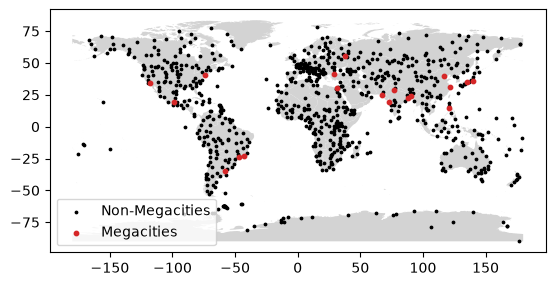

In [114]:
fig, ax = plt.subplots()

countries_gdf.plot(ax=ax, color='lightgrey')
non_megacities_gdf.plot(ax=ax, color='k', markersize=3, label='Non-Megacities')
megacities_gdf.plot(ax=ax, color='tab:red', markersize=10, label='Megacities')

ax.legend()

plt.show()

We can now ask the question: _what is the nearest megacity to each non-megacity?_

In [ ]:
nearest_megacity_gdf = gpd.sjoin_nearest(
    othercities_projected,
    megacities_projected[['NAME', 'geometry']],
    distance_col='distance_m'
)

nearest_megacity_gdf.head(5)

,NAME_left,ADM0NAME,ISO_A2,ADM1NAME,LATITUDE,LONGITUDE,POP_MAX,RANK_MAX,CAPIN,MEGACITY,geometry,index_right,NAME_right,distance_m
0,Bombo,Uganda,UG,Bamunanika,0.583299,32.533300,75000,8,None,0,POINT (3621590.334 64497.898),1239,Cairo,3.264506e+06
1,Fort Portal,Uganda,UG,Kabarole,0.671004,30.275002,42670,7,None,0,POINT (3370197.762 74195.826),1239,Cairo,3.253475e+06
2,Potenza,Italy,IT,Basilicata,40.642002,15.798997,69060,8,None,0,POINT (1758736.245 4500817.463),1228,Istanbul,1.467258e+06
3,Campobasso,Italy,IT,Molise,41.562999,14.655997,50762,8,None,0,POINT (1631498.079 4603099.608),1228,Istanbul,1.595054e+06
4,Aosta,Italy,IT,Valle d'Aosta,45.737001,7.315003,34062,7,None,0,POINT (814302.365 5066853.928),1228,Istanbul,2.467452e+06


You can see that we have two new columns at the far end: "`NAME_right"`, which contains the nearest megacity, and `"distance_m"`, which is the distance in CRS units (here, metres).

Note that because we have attempted to join a column called `NAME` to another dataset which already has a column called `NAME`, we've ended up with two slightly awkward renamed columns: `NAME_left` and `NAME_right`. As a final thing to neaten things up, we can rename these columns:

In [117]:
nearest_megacity_gdf = nearest_megacity_gdf.rename(
    columns={
        'NAME_left': 'NAME',
        'NAME_right': 'NEAREST_MEGACITY'
    }
)

nearest_megacity_gdf.head(5)

,NAME,ADM0NAME,ISO_A2,ADM1NAME,LATITUDE,LONGITUDE,POP_MAX,RANK_MAX,CAPIN,MEGACITY,geometry,index_right,NEAREST_MEGACITY,distance_m
0,Bombo,Uganda,UG,Bamunanika,0.583299,32.533300,75000,8,None,0,POINT (3621590.334 64497.898),1239,Cairo,3.264506e+06
1,Fort Portal,Uganda,UG,Kabarole,0.671004,30.275002,42670,7,None,0,POINT (3370197.762 74195.826),1239,Cairo,3.253475e+06
2,Potenza,Italy,IT,Basilicata,40.642002,15.798997,69060,8,None,0,POINT (1758736.245 4500817.463),1228,Istanbul,1.467258e+06
3,Campobasso,Italy,IT,Molise,41.562999,14.655997,50762,8,None,0,POINT (1631498.079 4603099.608),1228,Istanbul,1.595054e+06
4,Aosta,Italy,IT,Valle d'Aosta,45.737001,7.315003,34062,7,None,0,POINT (814302.365 5066853.928),1228,Istanbul,2.467452e+06


There is a key weakness to this analysis, and it is to do with the fact we have chosen a global dataset and a projected CRS. Can you work out what it is? Hint: it will have to do with settlements that cluster around the international date line.

This is a simple dataset with a simple example, but once again we can think about potentially useful applications. For a dataset of house locations, we could figure out the nearest bus stop, or hospital, or railway stations. We could figure out how far sampling sites are from rivers, or how far earthquakes are from major citiees.

## Summary

We have covered a number of ways you can begin to compare datasets within GeoPandas using spatial relationships: relating datasets based on how they intersect, overlap, and are located near each other in space. We can 'move' columns from one dataset to another based on these relationships, and begin to extract interesting things from these datasets.